Quick summary and progress updatre (07/03/2026)

The model that calibrates the CPI is now ready and published on LinkedIn. The markdown source file in this computer is called Infl_PnC_v008b.ipynb. Before being published, the file was reviewed by 3 reputable life actuaries with around of at least 60 years experience between them. 

The file with the code for simulations is called Infl_PnCv008.ipynb. This file and the subsequent ones will take the set up for the simulations as a given and will start from there. We repeat minimal code to calibrate and simulate at the start. 

Our next steps are: 
1. Set up a portfolio (best estimate) of both assets and liabilities and upon that calculate the inflation SCR. 
2. Run sensitivities on the above. These should include:
    a. tests to ensure the model works as intended (e.g. if we increase/reduce the inflation linkage, does the SCR behave accordingly? etc)

    b. tweaks on the asset portfolio

    c. tweaks on the liability portfolio

    d. tweaks in the scenario calibration

    e. perhaps a sensitivity using RPI (from 1988 also) instead of CPI, but not explaining the calibration in detail. 

3. Create a shiny front-end and publish it in some website of my own. 
4. Write up and publish

### Skeleton
###### Completed items
1.	Build monthly CPI AR1 + GARCH + t , AR1 + NIG; both with seasonality; not last 12 months, but averages; that is the base “crunch” model; assume fully stochastic and last 12 months as starting point are inappropriate. - DONE
2.	Build annualised model of CPI as well; non-overlapping data; identify what characteristics this has; choose every different month for a starting point;
3.	Build annualised model with overlapping data; see how its potential simulated results differ from the previous models. 
4.	Calculate st devs at various tenors from BoE data, both YoY and spots; compare them to the two above models. 
5.	Apply whatever judgement is required based on the above points; consider need for stability over time vs keeping aligned with current market conditions; things that may change in the future and negate current beliefs (e.g. bank independence, isolasionism)
###### Next steps
6.	Construct a portfolio of LPI-linked liabilities of various linkages; (0/5, 3/5, 3/7,0/3.5 say). 
7.	Identify if it is possible for an LPI to be fully broken to a fixed and an IL component; if not, identify what needs to be done/how best to hedge risks.
8.	Construct a portfolio of assets that mirrors the liabs as closely as possible. Consider maximum durations for assets; assume plain swaps for what is left (interest / inflation). Identify risks by swaps if inflation is not going according to plan. That step might be hardest to do. 
9.	Calculate capital for portfolio on step 7
10.	Identify further option instruments (caplets/floorlets) that can enter/leave the portfolio and the prices at which this may happen. 
11.	Iterate between steps 7 and 9 using instruments (some or all of those) in step 10 attempting to find optimal matching strategy ; identify price that can be paid to buy derivatives (options) to minimise residual risks. 

For code of previous attempts to model inflation, see previous files 007 or smaller. 

## An inflation model for assessing LPI capital requirements - Part 2

### Introduction

Insurers and in particular Bulk annuity purchase providers need a model to calculate inflation risk capital for LPI liabilities. 
The model need to be flexible enough to accommodate ALM purposes; that is to identify the balance sheet impact from various inflation hedging strategies.

This is the second note in these series; in the first note we constructed and calibrated (with help from a Large Language model (or LLM or AI)) a robust model for CPI that is appropriate for LPI-linked portfolios. In this note we use that model to apply it to an artificially constructed LPI portfolio of assets and liabilities that should resemble the ones available in the market. AI will also be used to accelerate the production and visualisation of results. We will also create a tool that can be used by end-uses to tweak some levers on the portfolio and see the impact on Capital requirements. 

The data relevant for this exercise are:

on the asset side: 

- Fixed-interest bonds
- Inflation linked-bonds
- Inflation swaps
- Inflation swaptions

on the liability side:
- profiles of different LPI linkages
- split between deferred members and pensioners
- split between fixed and LPI (or other inflation linkage) liabilities. 

While this is an imaginary portfolio, the logic and steps should be easily applicable in an actual portfolio. 

This note is constructed as follows: 
- Section 2 describes the construction of the liability portfolio. 
- Section 3 identifies actual publicly available market instruments to attempt to hedge both interest and inflation and ensure the Matching adjustment criteria are being met - however credit risk and matching adjustment in stress is not considered further in this note
- Section 4 describes how an inflation stress is applied to that portfolio and the impact on own finds. 
- Section 5 shows SCR results from [] scenarios
- Setionn 6 presents various sensitivities to the SCR based on a number of different triggers. 
- Section 7 discusses very briefly any new findings in working with AI. This is an expansion of section 7 of the previous note.
- Appendix A shows key prompts and challenges supplied by the author to the AI. Would be great to get some feedback on those. 

### Final Model specification

#### 1. Data
Monthly **log inflation** is defined as  
$$
r_t = \log(\mathrm{CPI}_t) - \log(\mathrm{CPI}_{t-1}).
$$

#### 2. Model

The complete model is
$$
r_t = \mu + s_{m(t)} + c_t + x_t,
$$

where 

- $ \mu$ is the seasonality intercept, 
- $ m(t)\in\{1,\dots,12\}$ denotes the calendar month:
- $ s_2,\dots,s_{12}$ are monthly seasonal offsets, 
- $ x_t = \phi x_{t-1} + \varepsilon_t \,  , \qquad |\phi| < 1$
- $ c_t = \rho c_{t-1} + \eta_t \, , \qquad |\rho| < 1$
- $\varepsilon_t \sim \mathrm{NIG}(a,b,l,s)$, 
- $\eta_t \sim \mathcal{N}(0,\sigma_{\text{slow}}^2), \eta_t$ and $\varepsilon_t$ are independent and i.i.d over time,
- $x_0 = r_T - \mu - s_{11}$ is set as the last filtered value (The last data point is november 2025)
- Initial state for the slow component:  $ c_0 \sim \mathcal{N}\!\left(0,\frac{\sigma_{\text{slow}}^2}{1-\rho^2}\right). $

#### 3. Estimated parameters of the model:

##### A-priori parameters
We first allow for seasonality and establish the relevant parameters through OLS:  
$\mu = -0.0044 $

and seasonal dummy coefficients (relative to month 1):

$s_{m(1)} = 0 \\
s_{m(2)}  =     0.009101 \\
s_{m(3)}  =     0.008059 \\
s_{m(4)}  =      0.011631\\
s_{m(5)}  =      0.008047\\
s_{m(6)}  =      0.005766\\
s_{m(7)}  =     0.002492\\
s_{m(8)}  =    0.008392\\
s_{m(9)}  =   0.007668\\
s_{m(10)}  =    0.006467\\
s_{m(11)}  =    0.005513\\
s_{m(12)}  =    0.007455 $

The following parameters are for the model that allows for seasonality and attempts to capture the heavy-tails of the residuals. At this point the model does not target annualised IPV. 

- $\phi \approx 0.25$
- $a = 1.2641$
- $b = 0.4514$
- $l = -0.001118$
- $s = 0.002920$

This component captures short-term dynamics and tail behaviour.

##### Slow component (low-frequency dynamics)
- $\rho = 0.995$, (set arbitrarily to ensure the component has long memory; its half life for monthly sim steps is c11.5 years)
- IPV target: 2.0764% $==> \sigma_{\text{slow}} = 0.00019373$ (estimated using trial and error until simulated IPV $\approx$ target IPV)
- $c_0 \sim N\left(0, \frac{\sigma_{\text{slow}}^2}{1 - \rho^2} \right)$  (randomly initialised in each simulation for stationarity)
- Note that all $r_t, x_t, c_t$ are in log-monthly units; IPV is computed on annualised rates.

#### 4. Aggregation and validation
Annual inflation is obtained by aggregation of monthly log inflation:
$$
\pi^{(1y)}_t
= \exp\!\left(\sum_{i=1}^{12} r_{t+i}\right) - 1.
$$

# Calibration and simulation of CPI (from Part 1)

In [1]:
# Identify AR/MA/ARMA/ARIMA + ARCH/GARCH on monthly CPI index series
# Assumes: monthly_infl_data is a pandas DataFrame with columns:
#   - date column: Excel serial day number (e.g., 35293)
#   - index column: CPI index level

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.stattools import arma_order_select_ic
from nkutils import read_named_range_to_dataframe as rnr2df, print_stats
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats

# Optional: GARCH tests/models
try:
    from arch import arch_model
    _HAVE_ARCH = True
except Exception:
    _HAVE_ARCH = False


In [2]:

monthly_infl_data = rnr2df("GenericInflationNotes.xlsx", "CPI_HistMonth_Jan1988_Nov25", "CPI_dttbl")


df = monthly_infl_data.copy().iloc[:, :2]
df.columns = ["excel_date", "cpi"]
df["date"] = pd.to_datetime(df["excel_date"], unit="D", origin="1899-12-30")
df = df.sort_values("date").set_index("date")

r = np.log(df["cpi"]).diff().dropna()  # monthly log inflation

In [3]:
from scipy import stats
import statsmodels.api as sm

# slow component model determination; seasonality adjustement first; ar1; nig residuals; then slow component. 
def fit_seasonality_ar1_nig(monthly_infl_data: pd.DataFrame):
    # --- data ---
    df = monthly_infl_data.iloc[:, :2].copy()
    df.columns = ["excel_date", "cpi"]
    df["date"] = pd.to_datetime(df["excel_date"], unit="D", origin="1899-12-30")
    df = df.sort_values("date").set_index("date")

    r = np.log(df["cpi"]).diff().dropna()  # monthly log inflation

    # --- seasonality (fixed dummies: months 2..12 relative to month 1) ---
    X = pd.get_dummies(r.index.month, drop_first=True).astype(float)
    X.index = r.index
    seas = sm.OLS(r.values, sm.add_constant(X.values)).fit()

    mu = float(seas.params[0])
    mu_p = float(seas.pvalues[0])

    seas_coefs = pd.Series(seas.params[1:], index=X.columns).astype(float)
    seas_pvals = pd.Series(seas.pvalues[1:], index=X.columns).astype(float)

    seasonal_term = pd.Series(mu, index=r.index)
    for m in range(2, 13):
        seasonal_term.loc[r.index.month == m] += float(seas_coefs.get(m, 0.0))

    x = (r - seasonal_term).dropna()

    # --- AR(1) on x, no constant ---
    ar1 = ARIMA(x, order=(1, 0, 0), trend="n").fit()
    phi = float(ar1.params[0])
    phi_p = float(ar1.pvalues[0])

    resid = np.asarray(ar1.resid, dtype=float)

    # --- NIG fit on residuals ---
    a, b, loc, scale = stats.norminvgauss.fit(resid)
    ll_nig = float(np.sum(stats.norminvgauss.logpdf(resid, a, b, loc=loc, scale=scale)))

    # --- BIC on consistent basis: (seasonality OLS + AR1 Gaussian + NIG residual) ---
    # Use NIG log-likelihood for residuals; parameters counted explicitly.
    n = resid.size
    k = 1 + 11 + 1 + 4  # mu + 11 seasonal dummies + phi + NIG(a,b,loc,scale)
    bic = -2 * ll_nig + k * np.log(n)

    # --- print parameters/p-values ---
    print("n (monthly obs used in AR part):", n)
    print("\n=== Seasonality (OLS on monthly log inflation) ===")
    print(f"mu: {mu:.10f} (p={mu_p:.3e})")
    for m in range(2, 13):
        print(f"month_{m}: {seas_coefs[m]:.10f} (p={seas_pvals[m]:.3e})")

    print("\n=== AR(1) on seasonally adjusted series ===")
    print(f"phi: {phi:.10f} (p={phi_p:.3e})")

    print("\n=== NIG on AR innovations ===")
    print(f"a: {float(a):.10f}")
    print(f"b: {float(b):.10f}")
    print(f"loc: {float(loc):.10f}")
    print(f"scale: {float(scale):.10f}")
    print(f"loglik (NIG): {ll_nig:.6f}")

    print("\nBIC (Seasonality + AR(1) + i.i.d. NIG):", f"{bic:.6f}")

    return {
        "mu": mu,
        "mu_p": mu_p,
        "seas_coefs": seas_coefs,
        "seas_pvals": seas_pvals,
        "phi": phi,
        "phi_p": phi_p,
        "nig": {"a": float(a), "b": float(b), "loc": float(loc), "scale": float(scale)},
        "bic": float(bic),
        "last_x": float(x.iloc[-1]),
        "last_log_cpi": float(np.log(df["cpi"]).iloc[-1]),
        "last_date": df.index[-1],
    }

params = fit_seasonality_ar1_nig(monthly_infl_data)

n (monthly obs used in AR part): 454

=== Seasonality (OLS on monthly log inflation) ===
mu: -0.0043973617 (p=9.154e-16)
month_2: 0.0091012461 (p=4.361e-30)
month_3: 0.0080589824 (p=1.293e-24)
month_4: 0.0116308938 (p=1.620e-44)
month_5: 0.0080469357 (p=1.489e-24)
month_6: 0.0057656663 (p=4.861e-14)
month_7: 0.0024924161 (p=8.263e-04)
month_8: 0.0083918466 (p=2.524e-26)
month_9: 0.0076677696 (p=1.176e-22)
month_10: 0.0064670992 (p=5.019e-17)
month_11: 0.0055125410 (p=5.051e-13)
month_12: 0.0074546464 (p=2.248e-21)

=== AR(1) on seasonally adjusted series ===
phi: 0.2500076515 (p=3.067e-09)

=== NIG on AR innovations ===
a: 1.2641072040
b: 0.4513690320
loc: -0.0011181762
scale: 0.0029204668
loglik (NIG): 2047.906891

BIC (Seasonality + AR(1) + i.i.d. NIG): -3991.806130


/Users/nikos/Documents/KnowledgeBase/InflationAndLPI/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/Users/nikos/Documents/KnowledgeBase/InflationAndLPI/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/Users/nikos/Documents/KnowledgeBase/InflationAndLPI/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [4]:
TARGET = 0.025 # 0.020764  # annual within-path st.dev target  # 0.025 
PROJECTION_YEARS = 40

def simulate_monthly_model_to_annual_infl(params, nsims=100_000, HZ_years=PROJECTION_YEARS, seed=123):
    """
    Baseline monthly: r_t = mu + s_m + x_t,  x_t = phi x_{t-1} + eps_t, eps_t ~ NIG
    Returns infl_annual (nsims, HZ_years) as YoY % rates.
    """
    rng = np.random.default_rng(seed)

    mu = float(params["mu"])
    seas = params["seas_coefs"]         # pd.Series {2..12}
    phi = float(params["phi"])
    nig = params["nig"]

    steps = 12 * HZ_years

    x_prev = np.full(nsims, float(params["last_x"]), dtype=float)
    log_cpi = np.full(nsims, float(params["last_log_cpi"]), dtype=float)

    # annual CPI levels (year 0..HZ_years)
    cpi_annual = np.empty((nsims, HZ_years + 1), dtype=float)
    cpi_annual[:, 0] = np.exp(log_cpi)

    start_month = int(params["last_date"].month)
    month_seq = ((start_month + np.arange(1, steps + 1) - 1) % 12) + 1

    yr = 0
    for t in range(steps):
        m = int(month_seq[t])
        s_m = 0.0 if m == 1 else float(seas.get(m, 0.0))

        eps = stats.norminvgauss.rvs(
            nig["a"], nig["b"], loc=nig["loc"], scale=nig["scale"],
            size=nsims, random_state=rng
        )

        x = phi * x_prev + eps
        r_t = mu + s_m + x
        log_cpi += r_t
        x_prev = x

        if (t + 1) % 12 == 0:
            yr += 1
            cpi_annual[:, yr] = np.exp(log_cpi)

    infl_annual = cpi_annual[:, 1:] / cpi_annual[:, :-1] - 1.0
    return infl_annual

def simulate_with_slow_component_to_annual_infl(
    params, nsims=100_000, HZ_years=PROJECTION_YEARS, rho_slow=0.995, sigma_slow=0.0005,
    m0_mode="stationary", seed=123
):
    """
    Slow component:
      m_t = rho_slow * m_{t-1} + eta_t,  eta_t ~ N(0, sigma_slow^2)
      r_t = mu + s_m + m_t + x_t
    Returns infl_annual (nsims, HZ_years) as YoY % rates.
    """
    rng = np.random.default_rng(seed)

    mu = float(params["mu"])
    seas = params["seas_coefs"]
    phi = float(params["phi"])
    nig = params["nig"]

    steps = 12 * HZ_years

    x_prev = np.full(nsims, float(params["last_x"]), dtype=float)

    # initialise m_0
    if m0_mode == "stationary" and abs(rho_slow) < 1:
        m_std0 = sigma_slow / np.sqrt(1.0 - rho_slow**2)
        m_prev = rng.normal(0.0, m_std0, size=nsims)
    else:
        m_prev = np.zeros(nsims, dtype=float)

    log_cpi = np.full(nsims, float(params["last_log_cpi"]), dtype=float)

    cpi_annual = np.empty((nsims, HZ_years + 1), dtype=float)
    cpi_annual[:, 0] = np.exp(log_cpi)

    start_month = int(params["last_date"].month)
    month_seq = ((start_month + np.arange(1, steps + 1) - 1) % 12) + 1

    yr = 0
    for t in range(steps):
        m = int(month_seq[t])
        s_m = 0.0 if m == 1 else float(seas.get(m, 0.0))

        eta = rng.normal(0.0, sigma_slow, size=nsims)
        m_t = rho_slow * m_prev + eta

        eps = stats.norminvgauss.rvs(
            nig["a"], nig["b"], loc=nig["loc"], scale=nig["scale"],
            size=nsims, random_state=rng
        )
        x_t = phi * x_prev + eps

        r_t = mu + s_m + m_t + x_t
        log_cpi += r_t

        m_prev = m_t
        x_prev = x_t

        if (t + 1) % 12 == 0:
            yr += 1
            cpi_annual[:, yr] = np.exp(log_cpi)

    infl_annual = cpi_annual[:, 1:] / cpi_annual[:, :-1] - 1.0
    return infl_annual

def within_path_std(infl_annual):
    # mean (across sims) of within-path (across years) sample st.dev
    return float(np.mean(np.std(infl_annual, axis=1, ddof=1)))

def calibrate_sigma_slow_bisect(
    params, target_std=TARGET, rho_slow=0.995, nsims=100_000, HZ_years=40,
    sigma_lo=0.0, sigma_hi=0.01, max_iter=20, seed=123
):
    """
    Calibrate sigma_slow (with fixed rho_slow) so that mean within-path annual st.dev hits target.
    Uses bisection. Requires target within [f(lo), f(hi)].
    """
    def f(sig):
        infl = simulate_with_slow_component_to_annual_infl(
            params, nsims=nsims, HZ_years=HZ_years, rho_slow=rho_slow, sigma_slow=sig, seed=seed
        )
        return within_path_std(infl)

    f_lo = f(sigma_lo)
    f_hi = f(sigma_hi)
    if not (f_lo <= target_std <= f_hi):
        raise ValueError(f"Target not bracketed: f(lo)={f_lo:.6f}, f(hi)={f_hi:.6f}. Increase sigma_hi.")

    lo, hi = sigma_lo, sigma_hi
    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        f_mid = f(mid)
        if f_mid >= target_std:
            hi = mid
        else:
            lo = mid

    sigma_star = 0.5 * (lo + hi)
    achieved = f(sigma_star)
    return sigma_star, achieved

# params is your frozen Seasonality + AR(1) + NIG dict (mu, seas_effects, phi, nig, last_x, last_log_cpi, last_date)

# 1) baseline 100k
infl_base = simulate_monthly_model_to_annual_infl(params, nsims=100_000, HZ_years=40, seed=123)
base_std = within_path_std(infl_base)
print("Baseline mean within-path annual st.dev:", f"{base_std:.6f}")

# 2) calibrate slow component (fix rho_slow, solve for sigma_slow)
rho_slow = 0.995
sigma_star, achieved = calibrate_sigma_slow_bisect(params, target_std=TARGET, rho_slow=rho_slow,
                                                   nsims=100_000, HZ_years=40, sigma_hi=0.01, max_iter=18, seed=123)
print("Calibrated rho_slow:", rho_slow)
print("Calibrated sigma_slow:", f"{sigma_star:.8f}")
print("Achieved mean within-path annual st.dev:", f"{achieved:.6f}")

# 3) simulate again 100k with calibrated slow component
infl_sc = simulate_with_slow_component_to_annual_infl(params, nsims=100_000, HZ_years=40,
                                                      rho_slow=rho_slow, sigma_slow=sigma_star, seed=456)
sc_std = within_path_std(infl_sc)
print("Post-SC mean within-path annual st.dev:", f"{sc_std:.6f}")

Baseline mean within-path annual st.dev: 0.013280
Calibrated rho_slow: 0.995
Calibrated sigma_slow: 0.00025850
Achieved mean within-path annual st.dev: 0.025000
Post-SC mean within-path annual st.dev: 0.024997


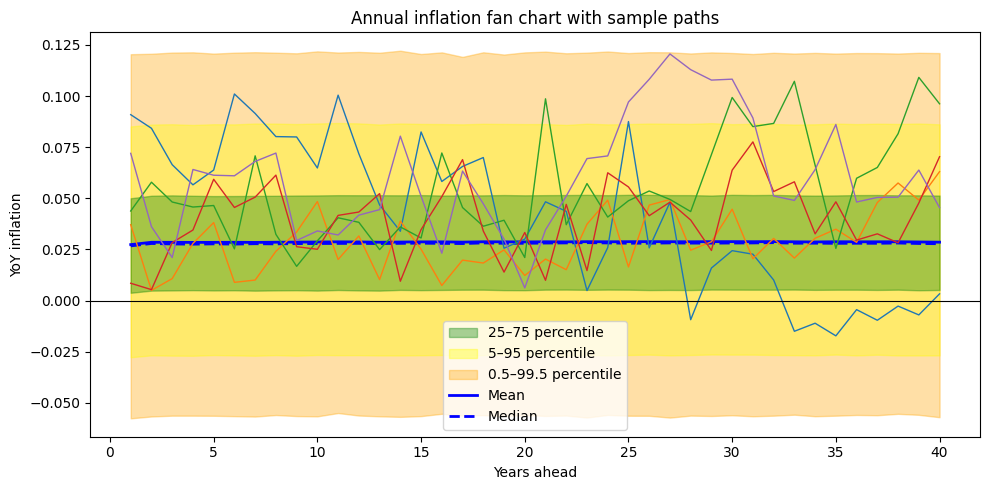

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_infl_fan_with_paths(infl_annual, seed=7, n_paths=5, k_list=(25, 5, 0.5)):
    """
    infl_annual: (nsims, HZ_years) YoY inflation rates (decimal, e.g. 0.02)
    Shades:
      k=25 -> 25–75 (green)
      k=5  -> 5–95   (yellow)
      k=0.5-> 0.5–99.5 (orange)
    """
    rng = np.random.default_rng(seed)
    nsims, HZ = infl_annual.shape
    years = np.arange(1, HZ + 1)

    # percentiles
    bands = {}
    for k in k_list:
        lo, hi = np.percentile(infl_annual, [k, 100 - k], axis=0)
        bands[k] = (lo, hi)

    plt.figure(figsize=(10, 5))

    h_orange = h_yellow = h_green = None

    if 0.5 in bands:
        lo, hi = bands[0.5]
        h_orange = plt.fill_between(years, lo, hi, alpha=0.35, color="orange")

    if 5 in bands:
        lo, hi = bands[5]
        h_yellow = plt.fill_between(years, lo, hi, alpha=0.35, color="yellow")

    if 25 in bands:
        lo, hi = bands[25]
        h_green = plt.fill_between(years, lo, hi, alpha=0.35, color="green")

    mean_line = np.mean(infl_annual, axis=0)
    med_line  = np.median(infl_annual, axis=0)

    h_mean, = plt.plot(years, mean_line, color="blue", linewidth=2)
    h_med,  = plt.plot(years, med_line,  color="blue", linestyle="--", linewidth=2)


    pick = rng.choice(nsims, size=min(n_paths, nsims), replace=False)
    for i in pick:
        plt.plot(years, infl_annual[i, :], linewidth=1)

    plt.axhline(0, color="black", linewidth=0.8)
    plt.title("Annual inflation fan chart with sample paths")
    plt.xlabel("Years ahead")
    plt.ylabel("YoY inflation")
    plt.tight_layout()
    plt.legend(
        handles=[h_green, h_yellow, h_orange, h_mean, h_med],
        labels=[
            "25–75 percentile",
            "5–95 percentile",
            "0.5–99.5 percentile",
            "Mean",
            "Median",
        ],
        loc="lower center"
    )
    plt.show()


def annual_stats_table(infl_annual):
    """
    Per simulation year stats across paths.
    """
    years = np.arange(1, infl_annual.shape[1] + 1)
    p = np.percentile(infl_annual, [0.5, 5, 25, 50, 75, 95, 99.5], axis=0)

    df = pd.DataFrame({
        "Year": years,
        "Mean": np.mean(infl_annual, axis=0),
        "Std":  np.std(infl_annual, axis=0, ddof=1),
        "P0.5": p[0],
        "P5":   p[1],
        "P25":  p[2],
        "P50":  p[3],
        "P75":  p[4],
        "P95":  p[5],
        "P99.5":p[6],
    })
    return df


def path_stats_table(infl_annual):
    """
    Per path stats across years (within-path).
    """
    mean_path = np.mean(infl_annual, axis=1)
    std_path  = np.std(infl_annual, axis=1, ddof=1)
    p_path = np.percentile(infl_annual, [0.5, 5, 50, 95, 99.5], axis=1)  # along years

    df = pd.DataFrame({
        "PathMean": mean_path,
        "PathStd": std_path,
        "PathP0.5": p_path[0],
        "PathP5":   p_path[1],
        "PathP50":  p_path[2],
        "PathP95":  p_path[3],
        "PathP99.5":p_path[4],
    })

    summary = pd.DataFrame({
        "Statistic": ["Mean(PathMean)", "Std(PathMean)", "Mean(PathStd)", "Std(PathStd)",
                      "P5(PathStd)", "P50(PathStd)", "P95(PathStd)"],
        "Value": [
            df["PathMean"].mean(),
            df["PathMean"].std(ddof=1),
            df["PathStd"].mean(),
            df["PathStd"].std(ddof=1),
            df["PathStd"].quantile(0.05),
            df["PathStd"].quantile(0.50),
            df["PathStd"].quantile(0.95),
        ]
    })
    return df, summary


plot_infl_fan_with_paths(infl_sc, seed=7, n_paths=5)

yearly = annual_stats_table(infl_sc)
# print(yearly.round(6))

per_path, per_path_summary = path_stats_table(infl_sc)
# print(per_path_summary.round(6))
# print(per_path.head(10).round(6))

In [18]:
N = 50
infl_toy_data = pd.DataFrame(infl_sc[0:N,:])
infl_toy_data.to_csv("infl_toy_paths.csv")

# literature

- Should commutation factors change? https://www.cambridge.org/core/services/aop-cambridge-core/content/view/1923F5B752C0B2412071F4DC8FDCD069/S1357321724000072a.pdf/div-class-title-the-exercise-of-discretion-on-commutation-factors-in-defined-benefit-schemes-time-for-change-div.pdf?utm_source=chatgpt.com





# Construction of liability portfolio

## Prompt leads to ChatGPT

1. Can you identify all possible forms of LPI that exist currently? its not just (0,5), its also (3,5), (3,7) etc. identify a percentage of the liabilities each of them represents. Split liabilities to immediate and deferred (again with percentages). build the percentages on data you find on the internet - list the sources you use to find the above.

2. imagine a scheme that has 2500 members. for these members, what is a reasonable age distribution? (also allowing for a 45%/55% deferred/pensioner split). lets start from there. I just want a simple set of values. assume that no benefits are to be accrued going forward.

3.  we are now in 2026. first of all, to make things smooth-ish, can you make assumptions for each individual's age as an integer, assuming there is a smoothly progressing number of people in each day. secondly, next to the year joined, also add a column with benefits acrued so far. be reasonable. assume benefit accrual stopped 3 years ago. assume each person accrued benefits smoothly over their lifetime. let me know if you need any moreb info.

4. yes, please. so the previous structure assumed an age distribution and a monetary amount. now we need to split this amount into trances, depending on when it has been accrued by each member. I would imagine the minimum accrual age is 21 (for simplicity). so if a member is 85 (say) today, and they retired at 65 (say), and they accrued since they were 21, that means accrual started 64 years ago, in 1962, correct? Similarly, someone who is 35 today will have only accrued for 14 years, so they will have not accrued any pre-2005 pension, all their accrual will be Post-2005. We could make it even more realistic and assume a mix between low-paid and high-paid employees, but lets say everyone accrued the same amount in a particular year. assume accrual was a percentage of final salary. if one worked for 40 years they would get the maximum which would be 2/3rds of final salary, although if final salary was 100K (say), then one would have a pension of 66.7K/year, but this would be of various fixed and LPI flavours. Can you work out some code to do these kind of calculations and come up with a pension accrued to date table, where different types of accrual (e.g. LPI3,5, RPI) are shown in separate columns ?

5. well, I just noticed the final salary of someone who is 37 today is 30000 while for someone who is 88 its around 90-100K. does this look reasonable to you ? Also, since they all accrue as % of final salary, which is not yet known, would it not be more prudent to record % of pension that falls in each trance, rather than a monetary amount, which is yet unknown for deferreds (because their final salary is also unknonw) ?

6. i believe deferred members are subject to a revaluation rate, not their actual final salary, is that right?

7. i like the 125% for reaching final salary from average. its very simple and thats good. 

you are right, there is randomness all over the place and one can create a super-complex set of rules to come up with a scheme and benefit membership, but we just need sufficient complexity to get LPI "cliffs" so to speak and to be realistic enough; reality will always be a tad more complex (for example due to a small number of active members) but we dont need to worry about that for the time being. 

so, to begin with, why dont you come up with a pattern of average final salaries that cover the full period over which they are relevant. then I'll talk you through over the next steps. 

  



At this point there is no reason to be overly precise with the construction of liabilities, as we represent an artificial portfolio, as long as our portfolio is reasonably realistic. Nevertheless, we still need to allow for a sufficient level of complexity that will let us build a reasonably complex set. 

We consider a portfolio as follows: 

oldest person is 95, receiving a pension. 
benefit accrual stopped in 2022. 
we are now on 1st January 2026.
the company hired 100 people each year until the scheme accrual ceased. so the scheme has currently no active members. 
everyone was hired at the age of 30
everyone retires at 65. 
there is no mortality prior to 65. 
from the 100 people at each cohort, 10,9,7,6 leave service after 5,10,15 and 20 years. The rest (66) complete 35 years of service and then retire.
we use a single mortality table from age 65 onwards. very crudely, we allow for dependands pensions by reducing the mortality rate at each age by 10%. We do not allow for mortality improvements.

while the above setup might appear fairly simplistic, it still allows for sufficient complexity in terms of inflation modelling, as follows: 
someone who is 64 years old on 1/1/2026 has the foloowing earning slices:
- post-88 GMP - it could inflate in deferrment at Average Weekly Earnings, for simplicity we assume a fixed revaluation rate as per government rules
- pre-97 excess - for simplicity we assume revaluation at the less of 5% and CPI, although it will vary by scheme. 
- pre-2009 revaluation at the less of 5% and CPI
- post-2009 revaluation at the less of 2.5% and CPI.

when someone reaches retirement: 
- those who have 5 or 10 years of service take their full benefit as cash
- the rest take 25% of their pot as cash
- they take the rest as pension. 

That poses a question about what commutation factors (CF) to use. the key contributors to CF are age at retirement, prevaling interest rates, mortality and inflation, to the extend that pension payments are linked to it. while in theory this should vary by member, in practice many schemes use the same factors for many members. We built a set of commutation factors to allow the calculation of lump sums that members (currently in deferrment) are expected to extract when reaching retirement age to add a bit more realism to the base cashflow profile. The assumptions about these factors are shown in Appendix []. 

[for appendix on commutation factors]
As can be found in literature, CFs do not vary by member and are usually at the discretion of trustess, and subject to actuarial advice. For this exercise we make the following assumptions;

The mortality table used (also for projecting cashflows of pensioners) is as shown below. Note that the mortality aspects of the projection are not up to scrutiny - a longevity specialist could produce more realistic inputs. 
[insert mortality table here - state source]

- Everyone retires at 65. 
- To allow for dependants/spouces, we apply a 10% reduction to each mortality rate up to the age of 100. 
- To allow for mortality improvements, for each future year we reduce mortality rates by 1% up to 10% (i.e. no further improvements after 10 years)
- it is assumed pensions have a 30% fixed and a 70% LPI(0,2.5%) component. 
- discount rates are based on the BoE spot rates up to term 40 for retirement in 2026 (the base yield curve). For future retirements, future yield curves are built from the base yield curve. interest rates beyond 40 years are set equal to the 40-year spot rate. 
- it is noted that on 31/12/2025 the difference between nominal and real rates implied spot inflation rates in excess of 2.5% on most durations. We have therefore defined the real spot rate as the maximum of nominal rate less 2.5% and the real spot rate from the BoE website. This increased the discount factors for inflation-linked liabilities, effectively making most liabilities fixed (note - this is only for setting up the CFs and no other purposes)
- the resulting CFs were further reduced by 5% as would typically happen to protect the benefits of the remaining pensioners. 


this resulted in the following set of CFs for the next 17 years:
15.01,14.8,14.61,14.42,14.27,14.15,14.07,14.02,14.00,14.01,14.05,14.09,14.15,14.22,14.31,14.25,14.25
we keep the CF constant beyond that term to 14.25. 
There is a question on whether interest rates (which are a big driver for CFs) would remain unchanged in a stochastic inflation projection. This is parked for now. 
Sensitivity of the results to the CFs is not considered as part of this analysis. 

We have made no allowance for: 
- age at exit
- sex
- guarantee periods

The pension has again several slices; 
- pre-78 component
- pre-88 GMP (which does not escalate)
- post-88 GMP (escalating at LPI(0,3))
- pre-97 excess 
- pre-2009 component 
- post 2009 component

The following table summarises how benefits increase in deferrment and in payment, very broadly:
| Pension slice | Service period | Deferment revaluation | Pension increase (in payment) |
|---|---|---|---|
| Pre-1978 pension | Before 6 Apr 1978 | Scheme rules (deterministic/can ignore) | Scheme rules |
| Pre-88 GMP | 6 Apr 1978 – 5 Apr 1988 | Fixed-rate GMP revaluation (or Section 148 earnings index) | 0% by law |
| Post-88 GMP | 6 Apr 1988 – 5 Apr 1997 | Fixed-rate GMP revaluation (or Section 148 earnings index) | CPI capped 3% |
| Pre-86 excess over GMP | 1978–1985 service above GMP | No revaluation  | 0% by law |
| Post-86 excess over GMP | 1986–1997 service above GMP | RPI capped 5% historically (statutory now CPI capped 5%) | 0% by law |
| Post-97 accrual | 6 Apr 1997 – 5 Apr 2005 | RPI capped 5% historically (statutory now CPI capped 5%) | RPI capped 5% historically (statutory now CPI capped 5%) |
| Post-2005 accrual | 6 Apr 2005 – 5 Apr 2009 | RPI capped 5% historically (statutory now CPI capped 5%) | RPI capped 2.5% historically (statutory now CPI capped 2.5%) |
| Post-2009 accrual | 6 Apr 2009 onward | CPI capped 2.5% | CPI capped 2.5% |

- note that many pension schemes are still contractually bound to RPI. Historically, RPI has been above CPI by about 0.5% to 1.0%. However, from 2030 the method of measuring RPI will change and RPI will be replaced by CMIH. This metric, while still not the same as CMI (since it will include housing costs) it will be much closer to it, probaly between 0.1% and 0.3% away from CPI. That will make hedging to CPI much more reliable.
- in the code we apply a simplification - we only have one split between 78 and 97, at year 88, as per GMP split; so the excess is not accurately split; this does not have material impact for this study.
- for simplicity, we have a single commutation factor for each future year of retirement which is primarily driven by the yield curve on the valuation date. We also assume that people took 25% of each slice of their pension as cash at their retirement. This is somewhat simplistic, as it is typical for people with a smaller number of years of service to take their full pot as cash.
- we have assumed that 5% increases are RPI based while 2.5% increases are CPI-based (both deferment and payment). The code at the moment does not offer flexibility to change the measure (from RPI to CPI) mid-way through a calculation, as could be the case in some pension schemes, at least in theory. 
- some naming conventions are unfortunate, pointing to a particular scheme - they need to be more generic (needs fixing).

Add the below into an appendix, as they support the table above, well some parts of it: 

(all rows apart from pre-78 are validated. mistakes in pre-78 deferment dont matter (deterministic). only pre-78 pension in payment increases need review.)

#### Appendix
Sources correct as in March 2026

Indexation
Schemes must increase pensions in payment annually if the pension rights were accrued after April 1997. They index (increase) these pensions in line with prices. There is a cap of 5% on annual increases for pension rights earned between April 1997 and April 2005. For rights earned after April 2005, the cap is 2.5%.

**Schemes do not need to index pension rights accrued before April 1997. While there have been calls for this to change, successive governments have committed to a broad principle of not imposing requirements retrospectively.**

Revaluation

Schemes must annually revalue deferred pension rights accrued since 1 January 1986 in line with prices. A cap of 5% applies for service to 5 April 2009 and at 2.5% for service after this.

https://commonslibrary.parliament.uk/research-briefings/sn05656/

(article 109)

(3)The percentage shall be—
    (a)the percentage by which that level has increased at the end of the period under review; or
    (b)3 per cent.,
    whichever is less.
[F3(3A)The relevant period is the period—
    (a)beginning with the tax year 1988-89, and
    (b)ending with the last tax year that begins before the principal appointed day

https://www.legislation.gov.uk/ukpga/1993/48/part/V/chapter/II


For preserved pension based on pensionable service carried out before 6 April 2009,
the increase must be at least in line with the increase in the general level of prices
over the whole period of deferment or 5% compound per annum whichever is the
lower. The Pensions Act 2008 reduced the 5% 'cap' to 2.5% compound per annum for
pension based on service from 6 April 2009, though schemes may continue to use the
higher cap under scheme rules. 

https://www.legislation.gov.uk/uksi/2010/2861/pdfs/uksiem_20102861_en.pdf

2.1 This instrument sets out the minimum required level of revaluation for pension rights
(excluding Guaranteed Minimum Pensions) of people who were early leavers from
defined benefit final salary occupational pension schemes, on or after 1 January 1986,
where the accrued rights have been left in the scheme. 

...

7.4 Pensions based on pensionable service before 6 April 2009 must be increased at least
in line with the increase in the general level of prices over the whole period of
deferment or 5 per cent compound per annum, whichever is lower. 

...

7.9 As a minimum, pensions put into payment before 6 April 2005 must be increased by
the increase in the general level of prices with a cap of 5 per cent. Pensions taken on
or after 6 April 2005 must, as a minimum, be increased by the increase in the general
level of prices with a cap of 5 per cent where the rights were accrued between 6 April
1997 and 5 April 2005 and a cap of 2.5 per cent where the pension rights were
accrued on or after 6 April 2005. The figures to be used for indexation are those
given for the one-year revaluation period in the annual Revaluation Order.

https://www.legislation.gov.uk/uksi/2022/1229/pdfs/uksiem_20221229_en.pdf




In [3]:
# unless I need stochastic cashflow projections, I can start from here. 

import os
import re
import numpy as np
import pandas as pd
from bisect import bisect

In [4]:
qx_s3pma = {
65:0.0080,66:0.0086,67:0.0092,68:0.0099,69:0.0107,
70:0.0116,71:0.0126,72:0.0138,73:0.0151,74:0.0166,
75:0.0183,76:0.0202,77:0.0224,78:0.0248,79:0.0276,
80:0.0307,81:0.0342,82:0.0381,83:0.0425,84:0.0474,
85:0.0529,86:0.0590,87:0.0658,88:0.0734,89:0.0818,
90:0.0912,91:0.1016,92:0.1131,93:0.1259,94:0.1401,
95:0.1558,96:0.1732,97:0.1924,98:0.2137,99:0.2372,
100:0.2631,101:0.290,102:0.320,103:0.353,104:0.389,
105:0.428,106:0.470,107:0.515,108:0.563,109:0.614,
110:0.667,111:0.721,112:0.775,113:0.826,114:0.871,
115:0.910,116:0.942,117:0.965,118:0.982,119:0.993,120:1.0
}

# scheme mortality allowing for dependants
qx_scheme = {age:0.9*v for age,v in qx_s3pma.items()}

In [11]:
CPI_BY_YEAR = pd.Series({
1966:0.039, 1967:0.025, 1968:0.047, 1969:0.054, 1970:0.064,
1971:0.092, 1972:0.072, 1973:0.090, 1974:0.163, 1975:0.243,
1976:0.166, 1977:0.154, 1978:0.083, 1979:0.134, 1980:0.183,
1981:0.119, 1982:0.085, 1983:0.046, 1984:0.050, 1985:0.060,
1986:0.034, 1987:0.042, 1988:0.049, 1989:0.075, 1990:0.094,
1991:0.059, 1992:0.037, 1993:0.016, 1994:0.025, 1995:0.027,
1996:0.024, 1997:0.018, 1998:0.016, 1999:0.013, 2000:0.008,
2001:0.012, 2002:0.013, 2003:0.014, 2004:0.013, 2005:0.021,
2006:0.023, 2007:0.023, 2008:0.036, 2009:0.022, 2010:0.033,
2011:0.045, 2012:0.028, 2013:0.026, 2014:0.015, 2015:0.000,
2016:0.007, 2017:0.027, 2018:0.025, 2019:0.018, 2020:0.009,
2021:0.026, 2022:0.091, 2023:0.067, 2024:0.030, 2025:0.030,
2026:0.025
}, dtype=float)


RPI_INDEX_BY_YEAR = pd.Series({
    1800: 13.5, 1801: 15.1, 1802: 11.6, 1803: 11.0, 1804: 11.3,
    1805: 13.1, 1806: 12.6, 1807: 12.3, 1808: 12.8, 1809: 14.0,
    1810: 14.4, 1811: 14.0, 1812: 15.9, 1813: 16.3, 1814: 14.2,
    1815: 12.7, 1816: 11.6, 1817: 13.2, 1818: 13.2, 1819: 12.9,
    1820: 11.7, 1821: 10.3, 1822: 8.9, 1823: 9.5, 1824: 10.3,
    1825: 12.1, 1826: 11.4, 1827: 10.7, 1828: 10.4, 1829: 10.3,
    1830: 9.9, 1831: 10.9, 1832: 10.1, 1833: 9.5, 1834: 8.7,
    1835: 8.9, 1836: 9.9, 1837: 10.1, 1838: 10.2, 1839: 10.9,
    1840: 11.1, 1841: 10.9, 1842: 10.0, 1843: 8.9, 1844: 8.9,
    1845: 9.3, 1846: 9.7, 1847: 10.9, 1848: 9.5, 1849: 8.9,
    1850: 8.4, 1851: 8.1, 1852: 8.1, 1853: 8.9, 1854: 10.2,
    1855: 10.5, 1856: 10.5, 1857: 10.0, 1858: 9.1, 1859: 9.0,
    1860: 9.3, 1861: 9.5, 1862: 9.3, 1863: 9.0, 1864: 8.9,
    1865: 9.0, 1866: 9.5, 1867: 10.1, 1868: 10.0, 1869: 9.5,
    1870: 9.5, 1871: 9.6, 1872: 10.0, 1873: 10.4, 1874: 10.0,
    1875: 9.8, 1876: 9.8, 1877: 9.7, 1878: 9.5, 1879: 9.1,
    1880: 9.4, 1881: 9.3, 1882: 9.4, 1883: 9.3, 1884: 9.1,
    1885: 8.8, 1886: 8.7, 1887: 8.6, 1888: 8.7, 1889: 8.8,
    1890: 8.8, 1891: 8.9, 1892: 8.9, 1893: 8.8, 1894: 8.7,
    1895: 8.6, 1896: 8.5, 1897: 8.7, 1898: 8.7, 1899: 8.8,
    1900: 9.2, 1901: 9.2, 1902: 9.2, 1903: 9.3, 1904: 9.3,
    1905: 9.3, 1906: 9.3, 1907: 9.4, 1908: 9.4, 1909: 9.5,
    1910: 9.6, 1911: 9.6, 1912: 9.9, 1913: 9.8, 1914: 9.8,
    1915: 11.0, 1916: 13.0, 1917: 16.3, 1918: 19.9, 1919: 21.9,
    1920: 25.3, 1921: 23.1, 1922: 19.9, 1923: 18.7, 1924: 18.6,
    1925: 18.6, 1926: 18.5, 1927: 18.0, 1928: 18.0, 1929: 17.8,
    1930: 17.3, 1931: 16.6, 1932: 16.2, 1933: 15.8, 1934: 15.8,
    1935: 15.9, 1936: 16.0, 1937: 16.6, 1938: 16.8, 1939: 17.3,
    1940: 20.2, 1941: 22.4, 1942: 24.0, 1943: 24.8, 1944: 25.5,
    1945: 26.2, 1946: 27.0, 1947: 28.9, 1948: 31.1, 1949: 32.0,
    1950: 33.0, 1951: 36.0, 1952: 39.3, 1953: 40.5, 1954: 41.3,
    1955: 43.1, 1956: 45.3, 1957: 46.9, 1958: 48.4, 1959: 48.6,
    1960: 49.1, 1961: 50.8, 1962: 53.0, 1963: 54.0, 1964: 55.8,
    1965: 58.4, 1966: 60.7, 1967: 62.3, 1968: 65.2, 1969: 68.7,
    1970: 73.1, 1971: 80.0, 1972: 85.7, 1973: 93.5, 1974: 108.5,
    1975: 134.8, 1976: 157.1, 1977: 182.0, 1978: 197.1, 1979: 223.5,
    1980: 263.7, 1981: 295.0, 1982: 320.4, 1983: 335.1, 1984: 351.8,
    1985: 373.2, 1986: 385.9, 1987: 402.0, 1988: 421.7, 1989: 454.5,
    1990: 497.5, 1991: 526.7, 1992: 546.4, 1993: 555.1, 1994: 568.5,
    1995: 588.2, 1996: 602.4, 1997: 621.3, 1998: 642.6, 1999: 652.5,
    2000: 671.8, 2001: 683.7, 2002: 695.1, 2003: 715.2, 2004: 736.5,
    2005: 757.3, 2006: 781.5, 2007: 815.0, 2008: 847.5, 2009: 843.0,
    2010: 881.9, 2011: 927.8, 2012: 957.6, 2013: 986.7, 2014: 1010.0,
    2015: 1020.0, 2016: 1037.7, 2017: 1074.9, 2018: 1110.8, 2019: 1139.3,
    2020: 1156.4, 2021: 1203.2, 2022: 1342.6, 2023: 1472.7, 2024: 1525.5,
    2025: 1588.6, 2026: 1603.2
}, dtype=float)

RPI_BY_YEAR = pd.Series({
    y: RPI_INDEX_BY_YEAR.loc[y] / RPI_INDEX_BY_YEAR.loc[y - 1] - 1.0
    for y in range(RPI_INDEX_BY_YEAR.index.min() + 1, RPI_INDEX_BY_YEAR.index.max() + 1)
}, dtype=float)

In [6]:
AE_BY_YEAR = pd.Series({
    1966: 880.0,
    1967: 950.0,
    1968: 1025.18,
    1969: 1105.13,
    1970: 1185.08,
    1971: 1309.36,
    1972: 1467.44,
    1973: 1674.66,
    1974: 1929.98,
    1975: 2510.04,
    1976: 2995.72,
    1977: 3297.32,
    1978: 3714.36,
    1979: 4236.70,
    1980: 5147.22,
    1981: 5771.74,
    1982: 6339.58,
    1983: 6878.30,
    1984: 7399.60,
    1985: 7930.00,
    1986: 8517.60,
    1987: 9105.20,
    1988: 9926.80,
    1989: 10883.60,
    1990: 11928.80,
    1991: 12838.80,
    1992: 13759.20,
    1993: 14211.60,
    1994: 14658.80,
    1995: 15095.60,
    1996: 15657.20,
    1997: 16718.00,
    1998: 17461.60,
    1999: 18007.60,
    2000: 18720.00,
    2001: 19624.80,
    2002: 20394.40,
    2003: 21070.40,
    2004: 21855.60,
    2005: 22448.40,
    2006: 23129.60,
    2007: 23883.60,
    2008: 24913.20,
    2009: 25474.80,
    2010: 26015.60,
    2011: 26000.00,
    2012: 26411.00,
    2013: 26915.00,
    2014: 27061.00,
    2015: 27482.00,
    2016: 28085.00,
    2017: 28704.00,
    2018: 29650.00,
    2019: 30498.00,
    2020: 31446.00,
    2021: 32819.00,
    2022: 34633.00,
    2023: 36791.00,
    2024: 38886.00,
    2025: 40946.00,
    2026: 42994.00,
}, dtype=float)

In [7]:
# =========================================================
# 2) MORTALITY TABLE
# ---------------------------------------------------------
# Replace this with your licensed CMI qx table if you have it.
# This is only a fallback placeholder structure.
# =========================================================

qx_table = {
    65:0.0080,66:0.0086,67:0.0092,68:0.0099,69:0.0107,
    70:0.0116,71:0.0126,72:0.0138,73:0.0151,74:0.0166,
    75:0.0183,76:0.0202,77:0.0224,78:0.0248,79:0.0276,
    80:0.0307,81:0.0342,82:0.0381,83:0.0425,84:0.0474,
    85:0.0529,86:0.0590,87:0.0658,88:0.0734,89:0.0818,
    90:0.0912,91:0.1016,92:0.1131,93:0.1259,94:0.1401,
    95:0.1558,96:0.1732,97:0.1924,98:0.2137,99:0.2372,
    100:0.2631,101:0.2900,102:0.3200,103:0.3530,104:0.3890,
    105:0.4280,106:0.4700,107:0.5150,108:0.5630,109:0.6140,
    110:0.6670,111:0.7210,112:0.7750,113:0.8260,114:0.8710,
    115:0.9100,116:0.9420,117:0.9650,118:0.9820,119:0.9930,
    120:1.0000
}

def survival_prob_to_age(current_age, qx_table, retirement_age=65, mortality_scale=0.90):
    if current_age <= retirement_age:
        return 1.0
    p = 1.0
    max_age = max(qx_table.keys())
    for age in range(retirement_age, current_age):
        qx = qx_table.get(age, qx_table[max_age])
        qx = min(1.0, mortality_scale * qx)
        p *= (1.0 - qx)
    return p

In [8]:


YEARS  = [1978, 1988, 1993, 1997, 2002, 2007, 2012, 2017, 2022, 2027]
RATES  = [0.0, 0.085, 0.075, 0.070, 0.0625, 0.045, 0.040, 0.0475, 0.035, 0.0325, 0.0325]

def gmp_fixed_rate(leaving_year: int) -> float:
    return RATES[bisect(YEARS, leaving_year)]

In [2]:
# =========================================================
# 1) SETTINGS
# =========================================================
VALUATION_YEAR = 2026
ACCRUAL_STOP_YEAR = 2022
FIRST_HIRE_YEAR = 1961          # hire at age 30 -> age 95 in 2026
LAST_HIRE_YEAR = 2022           # closed scheme, no hires after closure
HIRES_PER_YEAR = 100
HIRE_AGE = 30
RETIREMENT_AGE = 65
MORTALITY_SCALE = 0.90          # your dependant proxy
GMP_FRAC_78_88 = 0.25           # keep as-is
GMP_FRAC_88_97 = 0.25           # keep as-is
CASH_FACTOR = 0.25    # proportion of fund taken as pension at retirement
NA_SENTINEL = -999.0
# # ONS dataset URL found on the official ONS dataset page
# ONS_XLSX_URL = (
#     "https://www.ons.gov.uk/file?uri=%2Femploymentandlabourmarket%2Fpeopleinwork%2F"
#     "earningsandworkinghours%2Fdatasets%2Fearningstimeseriesofmediangrossweeklyearnings"
#     "from1968to2022%2Fcurrent%2F19682025.xlsx"
# )

OUTPUT_CSV = "Schemes/lpi_scheme_dataset_2026_with_amounts_v2.csv"

In [ ]:
# =========================================================
# 3) ONS AVERAGE EARNINGS SERIES
# ---------------------------------------------------------
# not required - removed

# =========================================================
# 4) GMP FIXED-RATE REVALUATION
# =========================================================
# simplified - see above. 

# =========================================================
# 5) SALARY MULTIPLIER VS AVERAGE EARNINGS
# ---------------------------------------------------------
# 5 years service  -> 80% of AE(year)
# 35 years service -> 125% of AE(year)
# linear interpolation in between
#
# For service < 5 caused by 2022 closure truncation, this floors at 80%.
# =========================================================
def salary_multiplier(service_years: float) -> float:
    if service_years <= 5:
        return 0.80
    if service_years >= 35:
        return 1.25
    return 0.80 + (service_years - 5.0) * (1.25 - 0.80) / (35.0 - 5.0)


def capped_deferment_factor(index_by_year: pd.Series, start_year: int, end_year: int, cap: float) -> float:
    """
    Applies cummulative revaluation from start_year to end_year using known annual inflation history.
    Applies for years start_year, ..., end_year-1.
    Example:
    leaving_year = 1990, valuation_year = 2026
    uses inflation for 1990, 1991, ..., 2025
    """
    if end_year <= start_year:
        return 1.0

    cumulative_inflation = 1.0
    for y in range(start_year, end_year):
        if y not in index_by_year.index:
            raise ValueError(f"Missing inflation data for year {y}")
        infl = float(index_by_year.loc[y])
        cumulative_inflation *= (1.0 + infl)

    years = end_year - start_year
    cumulative_cap = (1.0 + cap) ** years

    return min(cumulative_inflation, cumulative_cap)

# def split_known_future_revaluation(
#     amount_leave: float,
#     leaving_year: int,
#     retirement_year: int,
#     valuation_year: int,
#     index_by_year: pd.Series,
#     cap: float
# ):
#     """
#     For non-GMP deferred pension:
#     - apply known historical capped revaluation from leaving to min(retirement, valuation)
#     - leave only post-valuation revaluation as future, if retirement > valuation
#     Returns:
#         historical_factor_to_cutoff,
#         amount_at_cutoff,
#         years_future_to_65,
#         future_revaluation_needed
#     """
#     cutoff_year = min(retirement_year, valuation_year)

#     hist_factor = capped_deferment_factor(
#         index_by_year=index_by_year,
#         start_year=leaving_year,
#         end_year=cutoff_year,
#         cap=cap
#     )
#     amount_at_cutoff = amount_leave * hist_factor
#     years_future_to_65 = max(0, retirement_year - valuation_year)
#     future_revaluation_needed = retirement_year > valuation_year

#     return hist_factor, amount_at_cutoff, years_future_to_65, future_revaluation_needed

# =========================================================
# 6) CORE BUILD
# =========================================================
def overlap_years(start_a, end_a, start_b, end_b):
    return max(0, min(end_a, end_b) - max(start_a, start_b))


def capped_factor(index_by_year: pd.Series, start_year: int, end_year: int, cap: float) -> float:
    """
    Compound from start_year to end_year using annual inflation observations
    for years start_year, ..., end_year-1.
    """
    if end_year <= start_year:
        return 1.0
    f = 1.0
    for y in range(start_year, end_year):
        if y not in index_by_year.index:
            raise ValueError(f"Missing inflation data for year {y}")
        infl = float(index_by_year.loc[y])
        f *= (1.0 + min(infl, cap))
    return f

def build_scheme_dataset_with_amounts(
    ae_by_year: pd.Series,
    cpi_by_year: pd.Series,
    rpi_by_year: pd.Series,
    qx_table: dict,
    valuation_year=VALUATION_YEAR,
    accrual_stop_year=ACCRUAL_STOP_YEAR,
    first_hire_year=FIRST_HIRE_YEAR,
    last_hire_year=LAST_HIRE_YEAR,
    hires_per_year=HIRES_PER_YEAR,
    hire_age=HIRE_AGE,
    retirement_age=RETIREMENT_AGE,
    mortality_scale=MORTALITY_SCALE,
    gmp_frac_78_88=GMP_FRAC_78_88,
    gmp_frac_88_97=GMP_FRAC_88_97,
    cash_factor = CASH_FACTOR,
    output_csv=OUTPUT_CSV
):
    service_groups = [
        {"group_label": "leave_5",   "final_service_if_untruncated": 5,  "count_at_hire": 10},
        {"group_label": "leave_10",  "final_service_if_untruncated": 10, "count_at_hire": 9},
        {"group_label": "leave_15",  "final_service_if_untruncated": 15, "count_at_hire": 8},
        {"group_label": "leave_20",  "final_service_if_untruncated": 20, "count_at_hire": 7},
        {"group_label": "retire_65", "final_service_if_untruncated": 35, "count_at_hire": 66},
    ]

    rows = []

    for hire_year in range(first_hire_year, last_hire_year + 1):
        birth_year = hire_year - hire_age
        age_vd8 = valuation_year - birth_year
        retirement_year = birth_year + retirement_age
        status = "Deferred" if age_vd8 < retirement_age else "Pensioner"

        for g in service_groups:
            service_years = min(
                g["final_service_if_untruncated"],
                max(0, min(accrual_stop_year, retirement_year) - hire_year)
            )

            if service_years <= 0:
                continue

            leaving_year = hire_year + service_years

            members_alive = g["count_at_hire"]
            if status == "Pensioner":
                members_alive = round(
                    members_alive * survival_prob_to_age(
                        age_vd8, qx_table, retirement_age, mortality_scale
                    )
                )

            if members_alive == 0:
                continue

            # Service slices
            accrual_start_year = hire_year
            accrual_end_year = leaving_year

            svc_pre78 = overlap_years(accrual_start_year, accrual_end_year, -10**9, 1978)
            svc_78_88 = overlap_years(accrual_start_year, accrual_end_year, 1978, 1988)
            svc_88_97 = overlap_years(accrual_start_year, accrual_end_year, 1988, 1997)
            svc_97_05 = overlap_years(accrual_start_year, accrual_end_year, 1997, 2005)
            svc_05_09 = overlap_years(accrual_start_year, accrual_end_year, 2005, 2009)
            svc_09_22 = overlap_years(accrual_start_year, accrual_end_year, 2009, 2023)

            # Units at leaving
            units_gmp_pre88_leave = gmp_frac_78_88 * svc_78_88  # fixed scale in defer / no pension increases
            units_gmp_post88_leave = gmp_frac_88_97 * svc_88_97 # fixed scale in defer / CPI(0,3) in payment

#  notice slight discrepancy in the two formulae below wrt timing, which for the purpose of this study can be tolerated. 
            units_excess_pre86_fixed_leave = svc_pre78 + (1.0 - gmp_frac_78_88) * svc_78_88 # no reval in defer / no pension increases
            units_excess_86to97_leave = (1.0 - gmp_frac_88_97) * svc_88_97 # LPI(0,5) in defer / no pension increases

            units_97_05_rpi_0_5_leave = svc_97_05   # LPI(0,5) in defer / LPI(0,5) increases
            units_05_09_leave = svc_05_09  # LPI(0,5) in defer / LPI(0,2.5) increases
            units_09_22_cpi_0_25_leave = svc_09_22  # LPI(0,2.5) in defer / LPI(0,2.5) increases

            # Salary at leaving
            if int(leaving_year) not in ae_by_year.index:
                raise ValueError(f"Missing AE data for leaving_year={leaving_year}")

            ae_leave_year = float(ae_by_year.loc[int(leaving_year)])
            sal_mult = salary_multiplier(service_years)
            salary_at_leaving = sal_mult * ae_leave_year
            pension_per_unit_leave = salary_at_leaving / 60.0
            if int(leaving_year) not in cpi_by_year.index:
                raise ValueError(f"Missing CPI data for leaving_year={leaving_year}")
            if int(leaving_year) not in rpi_by_year.index:
                raise ValueError(f"Missing RPI data for leaving_year={leaving_year}")

            total_units_leave = (
                units_gmp_pre88_leave
                + units_gmp_post88_leave
                + units_excess_pre86_fixed_leave
                + units_excess_86to97_leave 
                + units_97_05_rpi_0_5_leave
                + units_05_09_leave
                + units_09_22_cpi_0_25_leave
            )

            # Monetary amounts at leaving
            gmp_pre88_amount_leave = units_gmp_pre88_leave * pension_per_unit_leave
            gmp_post88_amount_leave = units_gmp_post88_leave * pension_per_unit_leave
            amount_XS_pre86_fixed_leave = units_excess_pre86_fixed_leave * pension_per_unit_leave
            amount_XS_86to97_leave  = units_excess_86to97_leave * pension_per_unit_leave
            amount_97_05_rpi_0_5_leave = units_97_05_rpi_0_5_leave * pension_per_unit_leave
            amount_05_09_leave = units_05_09_leave * pension_per_unit_leave
            amount_09_22_cpi_0_25_leave = units_09_22_cpi_0_25_leave * pension_per_unit_leave

            # Monetary amounts at either retirement (GMP, due to fixed rules) or valuation date (if earlier, due to uncertainty)

            # GMP deterministic revaluation
            years_gmp_revaluation_to_65 = max(0, retirement_year - leaving_year)
            gmp_fix_rate = gmp_fixed_rate(leaving_year) if years_gmp_revaluation_to_65 > 0 else 0.0
            gmp_revaluation_factor_to_65 = (1.0 + gmp_fix_rate) ** years_gmp_revaluation_to_65 if years_gmp_revaluation_to_65 > 0 else 1.0

            units_gmp_pre88_at65 = units_gmp_pre88_leave * gmp_revaluation_factor_to_65
            units_gmp_post88_at65 = units_gmp_post88_leave * gmp_revaluation_factor_to_65
            amount_gmp_pre88_at65 = units_gmp_pre88_at65 * pension_per_unit_leave
            amount_gmp_post88_at65 = units_gmp_post88_at65 * pension_per_unit_leave

            # Historical deferment revaluation for non-GMP up to min(2026, 65)
            cutoff_year = min(retirement_year, valuation_year)  # for deferreds the cutoff year will be the valuation year - 
                                                                # no further calcs are needed after valuation date
            excess_pre86_fixed_at_cutoff = amount_XS_pre86_fixed_leave


            # In-payment historical escalation for pensioners to 2026
            if status == "Pensioner":  # then de-facto, retirement_year <= valuation_year
            #   pensioners have taken X% of each slice of their pension as cash at retirement    
            #   escalation factors to valuation date: 
                gmp_post88_inpay_factor_to_valnd8 = capped_factor(
                    cpi_by_year, retirement_year, valuation_year, 0.03
                ) if amount_gmp_post88_at65 > 0 else 1.0

                pre09_cap5pc_hist_factor = capped_deferment_factor(rpi_by_year, leaving_year, cutoff_year, 0.05)
                post09_cap2_5pc_hist_factor = capped_deferment_factor(cpi_by_year, max(2009, leaving_year), cutoff_year, 0.025)

                excess_pre86_fixed_at_cutoff = amount_XS_pre86_fixed_leave * 1.0 # fixed
                excess_86to97_cap5pc_at_cutoff =  amount_XS_86to97_leave * pre09_cap5pc_hist_factor
                amount_05_09_cutoff = amount_05_09_leave * pre09_cap5pc_hist_factor
                amount_09_22_cpi_0_25_cutoff = amount_09_22_cpi_0_25_leave * post09_cap2_5pc_hist_factor            

                LPI_5pc_to_valnd8 = capped_factor(rpi_by_year, cutoff_year, valuation_year, 0.05) if valuation_year > cutoff_year else 1.0
                LPI_2_5pc_to_valnd8 = capped_factor(cpi_by_year, cutoff_year, valuation_year, 0.025) if valuation_year > cutoff_year else 1.0
            #  pension amounts; there are 4 buckets; 
                pension_fixed_at_valnd8 = (amount_gmp_pre88_at65 + excess_pre86_fixed_at_cutoff  + excess_86to97_cap5pc_at_cutoff) \
                                        * (1 - cash_factor) # fixed after retirement
                pension_gmp_post88_at_valnd8 = amount_gmp_post88_at65 * gmp_post88_inpay_factor_to_valnd8 * ( 1- cash_factor)  # esc. at min (CPI,3%)
                
                amount_97_05_rpi_0_5_cutoff = amount_97_05_rpi_0_5_leave * pre09_cap5pc_hist_factor
                pension_LPI5pc_at_valnd8 = amount_97_05_rpi_0_5_cutoff * LPI_5pc_to_valnd8 * ( 1 - cash_factor)

                pension_LPI2_5pc_at_valnd8 = (amount_05_09_cutoff + amount_09_22_cpi_0_25_cutoff) \
                                        * LPI_2_5pc_to_valnd8 * ( 1 - cash_factor)


            else:  # status = "deferred" - escalation to retirement still relevant - maybe just merge the two fixed buckets, keep all else separate. 
                gmp_post88_inpay_factor_to_valnd8 = NA_SENTINEL
                LPI_5pc_to_valnd8 = NA_SENTINEL
                LPI_2_5pc_to_valnd8 = NA_SENTINEL
                pension_fixed_at_valnd8 = NA_SENTINEL
                pension_gmp_post88_at_valnd8 = NA_SENTINEL
                pension_LPI5pc_at_valnd8 = NA_SENTINEL
                pension_LPI2_5pc_at_valnd8 = NA_SENTINEL
# the 0.2 factor at the end of the next two statements exist because we really want an uncapped inflation figure and 
# historically inflation has not surpassed 15% for the period under investigation. 
                pre09_cap5pc_hist_factor = capped_deferment_factor(rpi_by_year, leaving_year, cutoff_year, 0.2)
                post09_cap2_5pc_hist_factor = capped_deferment_factor(cpi_by_year, max(2009, leaving_year), cutoff_year, 0.2)
                excess_86to97_cap5pc_at_cutoff = NA_SENTINEL
                amount_97_05_rpi_0_5_cutoff = NA_SENTINEL
                amount_05_09_cutoff = NA_SENTINEL
                amount_09_22_cpi_0_25_cutoff = NA_SENTINEL

            rows.append({
                "hire_year": hire_year,
                "birth_year": birth_year,
                "age_vd8": age_vd8,
                "retirement_year": retirement_year,
                "status": status,
                "group_label": g["group_label"],
                "members_alive": members_alive,
                "service_years": service_years,
                "leaving_year": leaving_year,

                "svc_pre_1978": svc_pre78,
                "svc_1978_1988": svc_78_88,
                "svc_1988_1997": svc_88_97,
                "svc_1997_2005": svc_97_05,
                "svc_2005_2009": svc_05_09,
                "svc_2009_2022": svc_09_22,

                "ae_leave_year": ae_leave_year,
                "salary_multiplier_to_AE": sal_mult,
                "salary_at_leaving": salary_at_leaving,
                "pension_per_service_unit_leave": pension_per_unit_leave,

                # units when leaving service or retirement (whichever is earlier)
                "total_units_leave": total_units_leave,

                "units_gmp_pre88_leave": units_gmp_pre88_leave,
                "units_gmp_post88_leave": units_gmp_post88_leave,
                "units_excess_pre86_fixed_leave": units_excess_pre86_fixed_leave,
                "units_excess_86to97_leave": units_excess_86to97_leave,
                "units_97_05_rpi_0_5_leave": units_97_05_rpi_0_5_leave,
                "units_05_09_leave": units_05_09_leave,
                "units_09_22_cpi_0_25_leave": units_09_22_cpi_0_25_leave,

                "gmp_pre88_amount_leave": gmp_pre88_amount_leave,
                "gmp_post88_amount_leave": gmp_post88_amount_leave,
                "amount_XS_pre86_fixed_leave": amount_XS_pre86_fixed_leave,
                "amount_XS_86to97_leave": amount_XS_86to97_leave,
                "amount_97_05_rpi_0_5_leave": amount_97_05_rpi_0_5_leave,
                "amount_05_09_leave": amount_05_09_leave,
                "amount_09_22_cpi_0_25_leave": amount_09_22_cpi_0_25_leave,

                "gmp_fixed_revaluation_rate": gmp_fix_rate,
                "years_gmp_revaluation_to_65": years_gmp_revaluation_to_65,
                "gmp_revaluation_factor_to_65": gmp_revaluation_factor_to_65,

                "gmp_pre88_units_at65": units_gmp_pre88_at65,
                "gmp_post88_units_at65": units_gmp_post88_at65,
                "gmp_pre88_amount_at65": amount_gmp_pre88_at65,
                "gmp_post88_amount_at65": amount_gmp_post88_at65,

                "pre09_cap5pc_hist_factor": pre09_cap5pc_hist_factor,
                "post09_cap2_5pc_hist_factor": post09_cap2_5pc_hist_factor,

                "excess_pre86_fixed_at_cutoff": excess_pre86_fixed_at_cutoff,
                "excess_86to97_cap5pc_at_cutoff": excess_86to97_cap5pc_at_cutoff,
                "amount_97_05_rpi_0_5_cutoff": amount_97_05_rpi_0_5_cutoff,
                "amount_05_09_cutoff": amount_05_09_cutoff, 
                "amount_09_22_cpi_0_25_cutoff": amount_09_22_cpi_0_25_cutoff, 

#   above information should be sufficient to project cashflows for deferreds - what follows will be for pensioners. 

                "gmp_post88_inpay_factor_to_valnd8": gmp_post88_inpay_factor_to_valnd8,
                "LPI_5pc_to_valnd8": LPI_5pc_to_valnd8, 
                "LPI_2_5pc_to_valnd8": LPI_2_5pc_to_valnd8, 
                "pension_fixed_at_valnd8": pension_fixed_at_valnd8, 
                "pension_gmp_post88_at_valnd8": pension_gmp_post88_at_valnd8, 
                "pension_LPI5pc_at_valnd8": pension_LPI5pc_at_valnd8, 
                "pension_LPI2_5pc_at_valnd8": pension_LPI2_5pc_at_valnd8

            })

    df = pd.DataFrame(rows)

    os.makedirs(os.path.dirname(output_csv), exist_ok=True)
    df.to_csv(output_csv, index=False)

    return df

# =========================================================
# 7) RUN
# =========================================================
ae_by_year = AE_BY_YEAR.loc[1966:2022]
cpi_by_year = CPI_BY_YEAR.loc[1966:2026]
rpi_by_year = RPI_BY_YEAR.loc[1966:2026]

df = build_scheme_dataset_with_amounts(
    ae_by_year=ae_by_year,
    cpi_by_year= cpi_by_year,
    rpi_by_year = rpi_by_year,
    qx_table=qx_table,
    valuation_year=VALUATION_YEAR,
    accrual_stop_year=ACCRUAL_STOP_YEAR,
    first_hire_year=FIRST_HIRE_YEAR,
    last_hire_year=LAST_HIRE_YEAR,
    hires_per_year=HIRES_PER_YEAR,
    hire_age=HIRE_AGE,
    retirement_age=RETIREMENT_AGE,
    mortality_scale=MORTALITY_SCALE,
    gmp_frac_78_88=GMP_FRAC_78_88,
    gmp_frac_88_97=GMP_FRAC_88_97,
    cash_factor = CASH_FACTOR, 
    output_csv=OUTPUT_CSV,
)

print(df.head(20))
print()
# print(summary_df)

# Validation checks run on the scheme dataset

## 1. Dataset integrity
- Check dataframe shape: number of rows and columns.
- Check that required columns exist.
- Check that `status` only takes expected values: `Deferred` and `Pensioner`.
- Check that rows do not contain missing variables caused by branch-specific assignments.

## 2. Timeline consistency
For each row, check that:
- `birth_year = hire_year - hire_age`
- `retirement_year = birth_year + 65`
- `leaving_year = hire_year + service_years`
- `leaving_year <= retirement_year`
- service truncation is consistent with the earlier of retirement and 2022 closure.

## 3. Service split consistency
Check that the service slices sum to `service_years`:

```python
svc_pre_1978 \
+ svc_1978_1988 \
+ svc_1988_1997 \
+ svc_1997_2005 \
+ svc_2005_2009 \
+ svc_2009_2022 \
= service_years
```

## 4. Unit consistency
Check that all leave-date unit buckets sum to `total_units_leave`:

```python
units_gmp_pre88_leave \
+ units_gmp_post88_leave \
+ units_excess_pre86_fixed_leave \
+ units_excess_86to97_leave \
+ units_97_05_rpi_0_5_leave \
+ units_05_09_leave \
+ units_09_22_rpi_0_25_leave \
= total_units_leave
```

## 5. Monetary consistency at leaving
For each slice, check:

```python
amount_slice_leave ≈ units_slice_leave * pension_per_service_unit_leave
```

Applied to:
- GMP pre-88
- GMP post-88
- pre-86 excess
- 86-97 excess
- 97-05 accrual
- 05-09 accrual
- 09-22 accrual

## 6. GMP revaluation sanity
Check that:

```python
gmp_revaluation_factor_to_65 = (1 + rate) ** (retirement_year - leaving_year)
```

and that:

```python
amount_gmp_*_at65 ≈ units_*_at65 * pension_per_unit_leave
```

## 7. Pensioner/deferred branch consistency
For deferred rows, check that pensioner-only fields are populated with the sentinel value rather than being undefined.

Examples:
- `gmp_post88_inpay_factor_to_valnd8`
- `LPI_5pc_to_valnd8`
- `LPI_2_5pc_to_valnd8`
- `pension_fixed_at_valnd8`
- `pension_gmp_post88_at_valnd8`
- `pension_LPI5pc_at_valnd8`
- `pension_LPI2_5pc_at_valnd8`

For pensioner rows, check that these fields are populated and not left at the sentinel.

## 8. Inflation factor behaviour
### Pre-2009 RPI 5% behaviour
For pensioners, test whether:

```python
pre09_cap5pc_hist_factor == (1.05) ** (retirement_year - leaving_year)
```

and confirm this is **not always true**.

For in-payment 5% increases, test whether:

```python
LPI_5pc_to_valnd8 == (1.05) ** (2026 - retirement_year)
```

and confirm this is **not always true**.

### Deferred historical accumulation
For deferreds, test whether the historical factor is being forced onto the cap path rather than reflecting accumulated inflation.

### Post-2009 CPI 2.5% behaviour
Check that:

```python
post09_cap2_5pc_hist_factor
```

is not mechanically equal to `1.025 ** n` in every case.

## 9. Monotonic sanity checks
- Inflation factors should generally be at least 1 unless deflation dominates.
- Longer deferment periods should generally produce larger historical factors, though not strictly in every path.

## 10. Structural sufficiency for future projection
For deferred rows, check that the file contains enough information to project to retirement:
- leave-date slice amounts
- `leaving_year`
- `retirement_year`
- GMP fixed-rate information
- historical cumulative inflation factors needed for pre-2026 accumulation

And check that projection does not rely on obsolete fields such as leave-date indices if those are no longer part of the design.


In [16]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(18, 10))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

def box(x, y, w, h, text):
    rect = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.01")
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=10)

def arrow(x1, y1, x2, y2, text):
    arr = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="->")
    ax.add_patch(arr)
    ax.text((x1+x2)/2, (y1+y2)/2 + 0.02, text, ha="center", fontsize=9)

# LEFT INPUTS
box(0.05, 0.7, 0.2, 0.2,
    "Pensioner Inputs\nage_2026\nmembers_alive\npension_*_at_valnd8")

box(0.05, 0.3, 0.2, 0.25,
    "Deferred Inputs\nleaving_year\nretirement_year\namount_*_leave\nhist inflation\ngmp rate")

# MIDDLE (deferred only)
box(0.4, 0.3, 0.2, 0.25,
    "Deferment Loop\nif < retirement:\nroll inflation\ntrack exposure\nif = retirement:\nproject + cap")

# RIGHT OUTPUTS
box(0.75, 0.7, 0.2, 0.2,
    "Pensioner Payments\nFixed\nCPI 3%\nRPI 5%\nCPI 2.5%")

box(0.75, 0.4, 0.2, 0.2,
    "Deferred Cash & Pensions\ncash 25%\nGMP C3\nRPI5\nCPI2.5")

box(0.75, 0.1, 0.2, 0.2,
    "Deferred Exposure\nRPI 5%\nCPI 2.5%")

# ARROWS
arrow(0.25, 0.8, 0.75, 0.8, "direct")
arrow(0.25, 0.4, 0.4, 0.4, "to deferment")
arrow(0.6, 0.4, 0.75, 0.5, "retirement")
arrow(0.6, 0.4, 0.75, 0.2, "pre-retirement")

out = "Schemes/cashflow_bucket_mapping_diagram.png"
plt.tight_layout()
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.close(fig)

print(out)


Schemes/cashflow_bucket_mapping_diagram.png


the code for producing the cashflows for these (and potentially a bunch of other) liabilities is under project_scheme_cashflows_vectorised.py


next, we start work to generate code to project asset cashflows, initially wthout looking at the liabilities 
(and therefore not worrying about volume of each asset required). we start with inflation derivatives. we will also be needing future interest rate information and potentially a model of stochastically generated discount rates. we start with basic swaps and we'll move up (complexity wise) over time. 



In [ ]:
from dataclasses import dataclass
import numpy as np
import pandas as pd


@dataclass
class InstrumentTerms:
    notional: float
    strike: float | None = None
    fixed_rate: float | None = None
    inception_premium: float = 0.0   # negative if paid, positive if received


def discount_factor_from_spot(spot_rate_pct: float, t_years: float) -> float:
    r = spot_rate_pct / 100.0
    return 1.0 / ((1.0 + r) ** t_years)


def make_discount_curve(spot_rates_pct: list[float]) -> pd.DataFrame:
    return pd.DataFrame({
        "t_years": np.arange(1, len(spot_rates_pct) + 1, dtype=float),
        "spot_rate_pct": spot_rates_pct,
    })


def _build_cashflow_table(
    payment_times: np.ndarray,
    float_leg: np.ndarray,
    fixed_leg: np.ndarray,
    premium_leg: np.ndarray,
    discount_curve: pd.DataFrame,
    inception_date: str = "2026-01-01",
) -> pd.DataFrame:
    spot_lookup = dict(zip(discount_curve["t_years"], discount_curve["spot_rate_pct"]))

    rows = [{
        "date_label": inception_date,
        "t_years": 0.0,
        "premium_leg": float(premium_leg[0]),
        "floating_leg": 0.0,
        "fixed_leg": 0.0,
        "option_payoff_leg": 0.0,
        "net_cashflow": float(premium_leg[0]),
        "discount_factor": 1.0,
        "pv_net_cashflow": float(premium_leg[0]),
    }]

    for k, t in enumerate(payment_times):
        df = discount_factor_from_spot(float(spot_lookup[float(t)]), float(t))
        fl = float(float_leg[k])
        fx = float(fixed_leg[k])
        opt = fl if fx == 0.0 else 0.0
        net = fl - fx
        rows.append({
            "date_label": f"{int(2026 + t)}-06-30",
            "t_years": float(t),
            "premium_leg": 0.0,
            "floating_leg": fl if fx != 0.0 else 0.0,
            "fixed_leg": fx,
            "option_payoff_leg": opt,
            "net_cashflow": net,
            "discount_factor": df,
            "pv_net_cashflow": net * df,
        })

    return pd.DataFrame(rows)

In [ ]:
# Example 1: RPI zero-coupon inflation swap

def rpi_zero_coupon_swap_cashflows(
    cumulative_rpi_factor: float,
    maturity_years: int,
    terms: InstrumentTerms,
    discount_curve: pd.DataFrame,
) -> pd.DataFrame:
    if terms.fixed_rate is None:
        raise ValueError("fixed_rate is required for a swap.")

    float_leg = np.array([terms.notional * cumulative_rpi_factor], dtype=float)
    fixed_leg = np.array([terms.notional * ((1.0 + terms.fixed_rate) ** maturity_years)], dtype=float)
    premium_leg = np.array([terms.inception_premium], dtype=float)

    return _build_cashflow_table(
        payment_times=np.array([float(maturity_years)]),
        float_leg=float_leg,
        fixed_leg=fixed_leg,
        premium_leg=premium_leg,
        discount_curve=discount_curve,
    )

In [ ]:
# Example 2: Year-on-year RPI swap

def rpi_yoy_swap_cashflows(
    annual_rpi_rates: np.ndarray,
    terms: InstrumentTerms,
    discount_curve: pd.DataFrame,
) -> pd.DataFrame:
    if terms.fixed_rate is None:
        raise ValueError("fixed_rate is required for a swap.")

    payment_times = np.arange(1, len(annual_rpi_rates) + 1, dtype=float)
    float_leg = terms.notional * (1.0 + annual_rpi_rates)
    fixed_leg = terms.notional * (1.0 + terms.fixed_rate)
    premium_leg = np.array([terms.inception_premium], dtype=float)

    return _build_cashflow_table(
        payment_times=payment_times,
        float_leg=float_leg,
        fixed_leg=np.full_like(float_leg, fixed_leg, dtype=float),
        premium_leg=premium_leg,
        discount_curve=discount_curve,
    )

In [ ]:
# Example 3: CPI / RPI basis swap

def cpi_rpi_basis_swap_cashflows(
    annual_cpi_rates: np.ndarray,
    annual_rpi_rates: np.ndarray,
    terms: InstrumentTerms,
    discount_curve: pd.DataFrame,
) -> pd.DataFrame:
    if len(annual_cpi_rates) != len(annual_rpi_rates):
        raise ValueError("CPI and RPI arrays must have the same length.")

    payment_times = np.arange(1, len(annual_rpi_rates) + 1, dtype=float)
    float_leg = terms.notional * (1.0 + annual_cpi_rates)
    fixed_leg = terms.notional * (1.0 + annual_rpi_rates)
    premium_leg = np.array([terms.inception_premium], dtype=float)

    return _build_cashflow_table(
        payment_times=payment_times,
        float_leg=float_leg,
        fixed_leg=fixed_leg,
        premium_leg=premium_leg,
        discount_curve=discount_curve,
    )

In [ ]:
# Example 4a/4b: RPI cap and RPI floor
def rpi_cap_cashflows(
    annual_rpi_rates: np.ndarray,
    terms: InstrumentTerms,
    discount_curve: pd.DataFrame,
) -> pd.DataFrame:
    if terms.strike is None:
        raise ValueError("strike is required for a cap.")

    payment_times = np.arange(1, len(annual_rpi_rates) + 1, dtype=float)
    option_leg = terms.notional * np.maximum(annual_rpi_rates - terms.strike, 0.0)
    premium_leg = np.array([terms.inception_premium], dtype=float)

    return _build_cashflow_table(
        payment_times=payment_times,
        float_leg=option_leg,
        fixed_leg=np.zeros_like(option_leg),
        premium_leg=premium_leg,
        discount_curve=discount_curve,
    )

def rpi_floor_cashflows(
    annual_rpi_rates: np.ndarray,
    terms: InstrumentTerms,
    discount_curve: pd.DataFrame,
) -> pd.DataFrame:
    if terms.strike is None:
        raise ValueError("strike is required for a floor.")

    payment_times = np.arange(1, len(annual_rpi_rates) + 1, dtype=float)
    option_leg = terms.notional * np.maximum(terms.strike - annual_rpi_rates, 0.0)
    premium_leg = np.array([terms.inception_premium], dtype=float)

    return _build_cashflow_table(
        payment_times=payment_times,
        float_leg=option_leg,
        fixed_leg=np.zeros_like(option_leg),
        premium_leg=premium_leg,
        discount_curve=discount_curve,
    )

In [ ]:
# Example usage

boe_spot_rates = [
    3.5533, 3.6325, 3.7124, 3.8164, 3.9366, 4.0663, 4.1992, 4.3299, 4.4547, 4.5716,
    4.6795, 4.7781, 4.8673, 4.9470, 5.0174, 5.0785, 5.1309, 5.1750, 5.2117, 5.2418,
    5.2663, 5.2859, 5.3012, 5.3128, 5.3210, 5.3259, 5.3276, 5.3261, 5.3212, 5.3130,
    5.3015, 5.2864, 5.2680, 5.2460, 5.2205, 5.1915, 5.1590, 5.1229, 5.0833, 5.0403,
]

disc = make_discount_curve(boe_spot_rates)

rpi_path = np.array([0.03, 0.025, 0.04, 0.015, 0.02])

cap_terms = InstrumentTerms(
    notional=100.0,
    strike=0.05,
    inception_cashflow=-2.75,   # premium paid
)

cap_cf = rpi_cap_cashflows(
    annual_rpi_rates=rpi_path,
    discount_curve=disc,
    terms=cap_terms,
)

print(cap_cf)

In [ ]:
# Example 5a / 5b; RPI Caplet / RPI Floorlet

def rpi_caplet_cashflows(
    realised_rate: float,
    payment_year: int,
    terms: InstrumentTerms,
    discount_curve: pd.DataFrame,
) -> pd.DataFrame:
    if terms.strike is None:
        raise ValueError("strike is required for a caplet.")

    option_leg = np.array([terms.notional * max(realised_rate - terms.strike, 0.0)], dtype=float)
    premium_leg = np.array([terms.inception_premium], dtype=float)

    return _build_cashflow_table(
        payment_times=np.array([float(payment_year)]),
        float_leg=option_leg,
        fixed_leg=np.zeros_like(option_leg),
        premium_leg=premium_leg,
        discount_curve=discount_curve,
    )

def rpi_floorlet_cashflows(
    realised_rate: float,
    payment_year: int,
    terms: InstrumentTerms,
    discount_curve: pd.DataFrame,
) -> pd.DataFrame:
    if terms.strike is None:
        raise ValueError("strike is required for a floorlet.")

    option_leg = np.array([terms.notional * max(terms.strike - realised_rate, 0.0)], dtype=float)
    premium_leg = np.array([terms.inception_premium], dtype=float)

    return _build_cashflow_table(
        payment_times=np.array([float(payment_year)]),
        float_leg=option_leg,
        fixed_leg=np.zeros_like(option_leg),
        premium_leg=premium_leg,
        discount_curve=discount_curve,
    )

In [ ]:
#  Example usage

boe_spot_rates = [
    3.5533, 3.6325, 3.7124, 3.8164, 3.9366, 4.0663, 4.1992, 4.3299, 4.4547, 4.5716,
    4.6795, 4.7781, 4.8673, 4.9470, 5.0174, 5.0785, 5.1309, 5.1750, 5.2117, 5.2418,
    5.2663, 5.2859, 5.3012, 5.3128, 5.3210, 5.3259, 5.3276, 5.3261, 5.3212, 5.3130,
    5.3015, 5.2864, 5.2680, 5.2460, 5.2205, 5.1915, 5.1590, 5.1229, 5.0833, 5.0403,
]
disc = make_discount_curve(boe_spot_rates)

rpi_path = np.array([0.03] * 40)

cap_terms = InstrumentTerms(
    notional=100.0,
    strike=0.05,
    inception_premium=-2.0,
)

swap_terms = InstrumentTerms(
    notional=100.0,
    fixed_rate=0.03,
    inception_premium=0.0,
)

cap_cf = rpi_cap_cashflows(rpi_path, cap_terms, disc)
swap_cf = rpi_yoy_swap_cashflows(rpi_path, swap_terms, disc)